# Testing Libraries

In [15]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1
!export BART_CPU_ONLY=1
!export CUDA_LAUNCH_BLOCKING=1

import importlib
import sys
import os

os.environ['BART_TOOLBOX_PATH'] = '/home/rinbha/bart-0.9.00'
os.environ['BART_CPU_ONLY'] = '1'
sys.path.append(os.path.join(os.environ['BART_TOOLBOX_PATH'], 'python'))
sys.path.append(os.path.abspath('/home/rinbha/orchestra-sdk-2.1-1.python/'))
sys.path.append('../')

sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/sigpy-custom")
sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/torch-interpol")
import sigpy as sp
import sigpy.plot as pl

import matplotlib.pyplot as plt
import numpy as np

# plotting
%matplotlib widget
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


## io

### Radial

In [16]:
# add paths
from bpt_motus.io import RadialArchive

In [17]:
import bpt_motus.io.radial_reader as rr
importlib.reload(rr)

from bpt_motus.io.radial_reader import RadialArchive

In [61]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/radial"

# Create the object
radial = RadialArchive(inpdir)

radial.get_ksp(force_reload=False)

INFO: Loading cached k-space from /mikLKS/rinbha/BPT/MRMOTUS/test_data/radial/raw_data/data_dict.pkl


In [62]:
for key in radial.data_dict.keys():
    print(f"{key} shape: {radial.data_dict[key].shape}")

xk_time shape: (22, 39950, 1633)
coords_time shape: (39950, 1633, 3)
dcf_time shape: (39950, 1633)
time_ordering shape: (39950,)


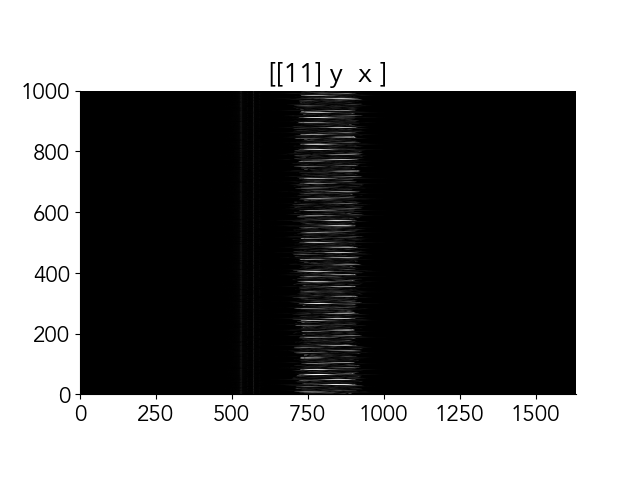

In [67]:
xk_f = sp.ifft(radial.data_dict['xk_time'], axes=(-1,))
pl.ImagePlot(xk_f[:,:1000])

In [68]:
del radial

### Bravo

In [25]:
from bpt_motus.io import BravoArchive

In [26]:
import bpt_motus.io.bravo_reader as br
importlib.reload(br)

from bpt_motus.io.bravo_reader import BravoArchive

In [27]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bravo"

# Create the object
bravo = BravoArchive(inpdir)

bravo.get_ksp(force_reload=False)

INFO: Loading cached k-space from /mikLKS/rinbha/BPT/MRMOTUS/test_data/bravo/raw_data/data_dict.pkl


In [28]:
for key in bravo.data_dict.keys():
    print(f"{key} shape: {bravo.data_dict[key].shape}")

xk_time shape: (22, 58520, 384)
xk_recon shape: (22, 384, 308, 190)
coords shape: (58520, 384, 3)


In [29]:
im_recon = sp.ifft(bravo.data_dict['xk_recon'], axes=(-1,-2,-3))

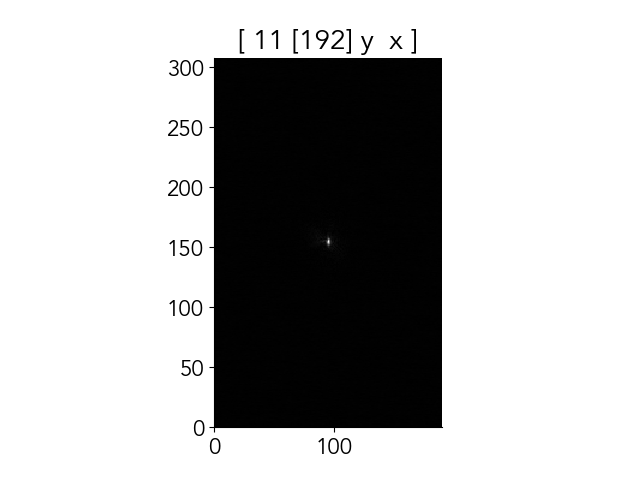

In [30]:
pl.ImagePlot(bravo.data_dict['xk_recon'])

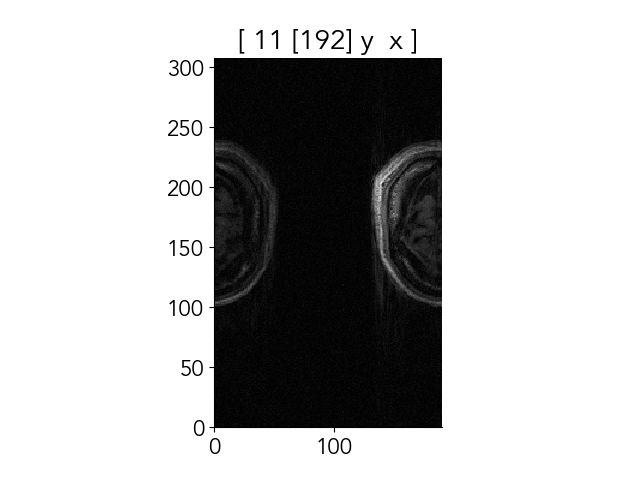

In [32]:
pl.ImagePlot(im_recon)

In [33]:
del bravo, im_recon

## preprocessing

### Split k-space and BPT

In [53]:
from bpt_motus.preprocessing import SplitXkBPT

In [54]:
import bpt_motus.preprocessing.split_xk_bpt as sxb
importlib.reload(sxb)

from bpt_motus.preprocessing.split_xk_bpt import SplitXkBPT

In [55]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/radial/"

# Create the object
split_xk_bpt = SplitXkBPT(inp_dir=inpdir, verbose=True)

In [56]:
split_xk_bpt.run()

INFO: Cleaned k-space and raw BPT/PT signals found. Opening...
INFO: Coil compressing k-space with PCA.


In [57]:
print(f"Cleaned k-space shape: {split_xk_bpt.xk_cleaned.shape}")
print(f"BPT/PTs shape: {split_xk_bpt.bpts.shape}")

Cleaned k-space shape: (6, 39950, 1633)
BPT/PTs shape: (4, 39950, 22)


In [58]:
split_xk_bpt.xk_cleaned.shape

(6, 39950, 1633)

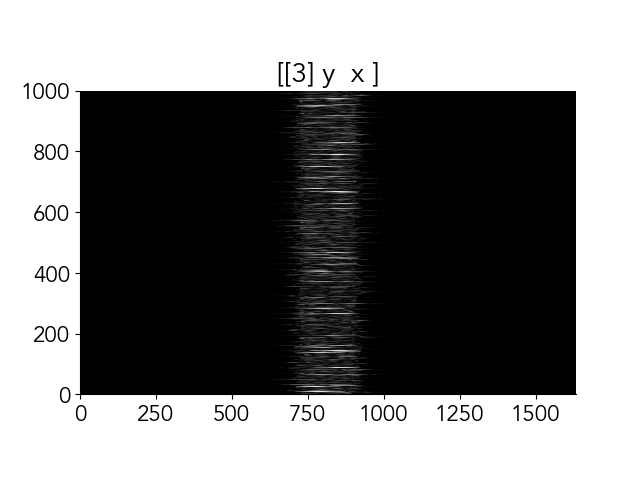

In [66]:
# xk_f_cleaned = sp.ifft(split_xk_bpt.xk_cleaned, axes=(-1,))
pl.ImagePlot(xk_f_cleaned[:,:1000])

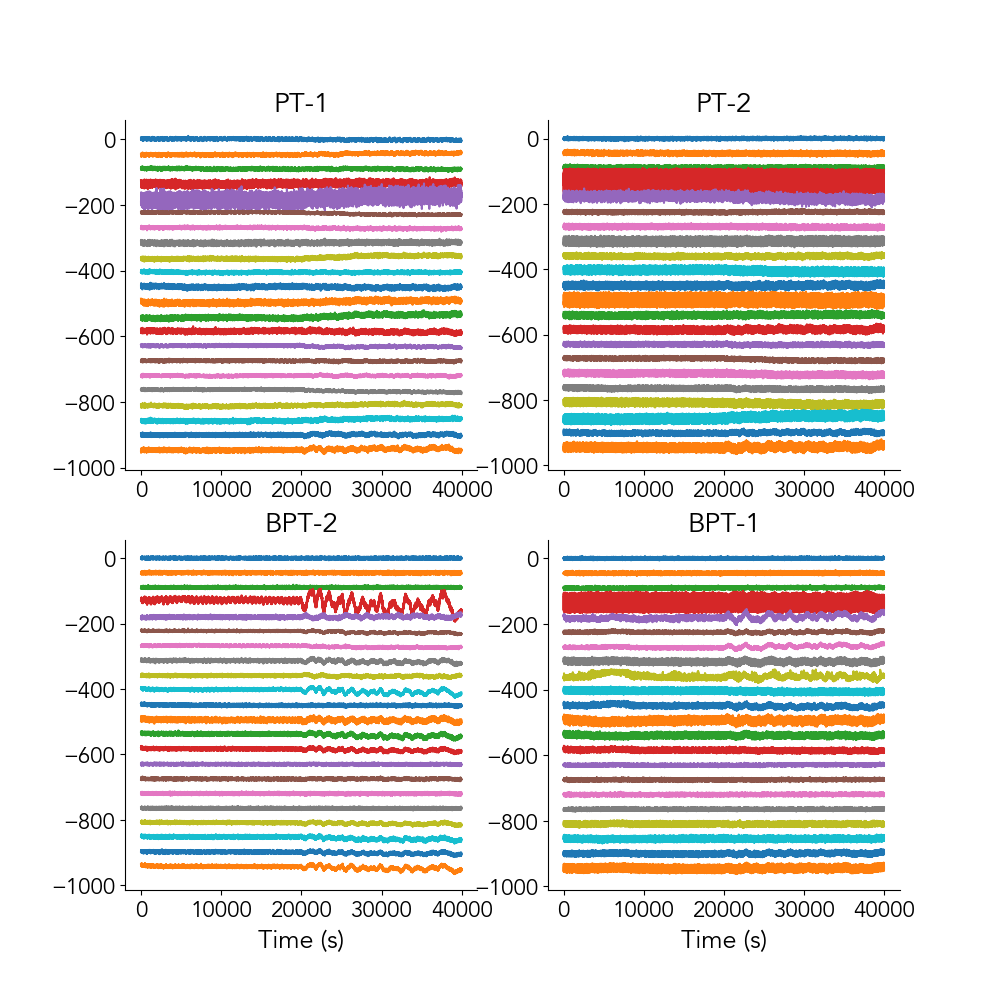

In [51]:
def plot_bpt(bpt, tr=1, window=1, shift=0, figsize=(10,10), titles = ["PT-1", "PT-2", "BPT-2", "BPT-1"]):
    nbpts, npe, ncoils = bpt.shape
    
    plt.figure(figsize=figsize)
    t = np.arange(npe)*tr
    # Plot
    for i in range(nbpts):
        plt.subplot(nbpts//2, 2, i+1)
        plt.plot(t, bpt[i] - np.mean(bpt[i],axis=0) + np.arange(ncoils)*shift);
        plt.title(titles[i])
        if i > 1:
            plt.xlabel("Time (s)")

plot_bpt(split_xk_bpt.bpts, shift = -45)

### Process xk

In [53]:
from bpt_motus.preprocessing import ProcessXk

In [54]:
import bpt_motus.preprocessing.process_xk as px
importlib.reload(px)

from bpt_motus.preprocessing.process_xk import ProcessXk

In [55]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/radial/"

# Create the object
split_xk_bpt = SplitXkBPT(inp_dir=inpdir, verbose=True)